# Solución del laboratorio 4: Sport Obermeyer: decidir bajo demanda incierta
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


perdidas_base
  q escenario  demanda  probabilidad  perdida  aporte
105      bajo     80.0          0.25     50.0    12.5
105   central    100.0          0.50     10.0     5.0
105      alto    140.0          0.25    280.0    70.0
140      bajo     80.0          0.25    120.0    30.0
140   central    100.0          0.50     80.0    40.0
140      alto    140.0          0.25      0.0     0.0

sensibilidad
       caso  cu  q_min_optimo  q_max_optimo  n_optimos  costo_optimo  q_media  costo_media
 faltante_2   2           100           100          1          30.0      105         35.0
 faltante_6   6           100           140         41          70.0      105         70.0
       base   8           140           140          1          70.0      105         87.5
faltante_12  12           140           140          1          70.0      105        122.5

curvas_costo
 q  faltante_2  faltante_6  base  faltante_12
 0       210.0       630.0 840.0       1260.0
 1       208.0       624.0 832.0

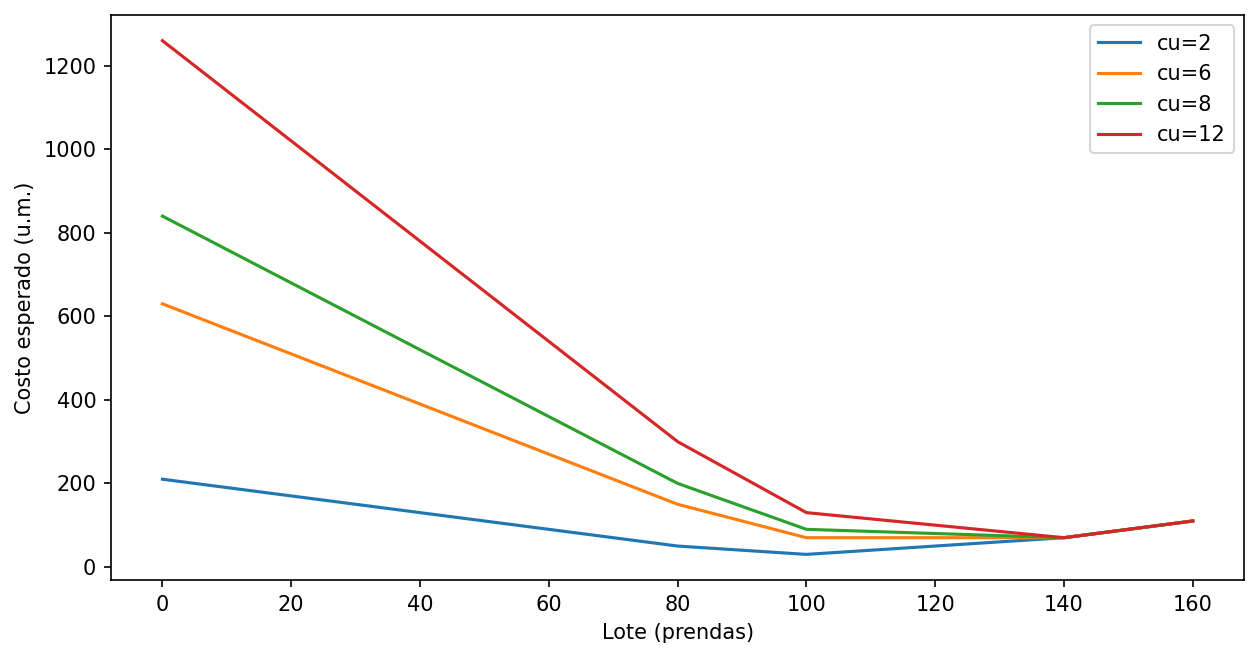

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

esc=pd.read_csv(datos / "demanda_escenarios.csv")
costos=pd.read_csv(datos / "costos_sensibilidad.csv")
D=esc.demanda_unidades.to_numpy(float); pi=esc.probabilidad.to_numpy(float)
assert np.all(pi>=0) and np.isclose(pi.sum(),1)
q=np.arange(parametros["q_min"],parametros["q_max"]+1,parametros["q_paso"])
q_media=int(round(D@pi))
filas=[]; curvas=pd.DataFrame({"q":q})
fig,ax=plt.subplots(figsize=(8.5,4.5))
for row in costos.itertuples():
    perdidas=(row.costo_faltante_um*np.maximum(D[None,:]-q[:,None],0)+
              row.costo_sobrante_um*np.maximum(q[:,None]-D[None,:],0))
    esperado=perdidas@pi
    optimos=q[np.isclose(esperado,esperado.min(),rtol=0,atol=1e-9)]
    costo_media=float(esperado[np.flatnonzero(q==q_media)[0]])
    filas.append({"caso":row.caso,"cu":row.costo_faltante_um,
                  "q_min_optimo":int(optimos.min()),"q_max_optimo":int(optimos.max()),
                  "n_optimos":len(optimos),"costo_optimo":float(esperado.min()),
                  "q_media":q_media,"costo_media":costo_media})
    curvas[row.caso]=esperado
    ax.plot(q,esperado,label=f"cu={row.costo_faltante_um:g}")
    if row.caso=="base":
        base=filas[-1]
        detalles=[]
        for cantidad in [q_media,int(optimos.min())]:
            for s,d,p in zip(esc.escenario,D,pi):
                perdida=row.costo_faltante_um*max(d-cantidad,0)+row.costo_sobrante_um*max(cantidad-d,0)
                detalles.append({"q":cantidad,"escenario":s,"demanda":d,
                                  "probabilidad":p,"perdida":perdida,"aporte":p*perdida})
        tabla(pd.DataFrame(detalles),"perdidas_base")
tabla(pd.DataFrame(filas),"sensibilidad")
tabla(curvas,"curvas_costo")
ax.set(xlabel="Lote (prendas)",ylabel="Costo esperado (u.m.)")
ax.legend(); figura(fig,"costo_esperado")
assert base["q_min_optimo"]==140 and base["costo_optimo"]==70
assert base["costo_media"]==87.5
resumen({"media":q_media,"escenarios_costos":filas})
